# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [2]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from Bio import Entrez

Entrez.email = "mariokujbida@outlook.com"
print("ok")

ok


In [4]:
df_novo = pd.read_csv('exercicio_10.csv', index_col='Unnamed: 0').T
print(df_novo)

      Caracteres Inicio_nomes Contagem_A Tem_HU
HDAC1          5           HD          1  False
HDAC2          5           HD          1  False
HDAC3          5           HD          1  False
HDAC4          5           HD          1  False
HDAC5          5           HD          1  False


In [5]:
from Bio import SeqIO

In [7]:
arquivos = [
    "HDAC1.fasta",
    "HDAC2.fasta",
    "HDAC3.fasta",
    "HDAC4.fasta",
    "HDAC5.fasta"
]

for arquivo in arquivos:
    for record in SeqIO.parse(arquivo, "fasta"):
        print(arquivo)
        print("ID:", record.id)
        print("Sequência:", record.seq)
        print("-" * 30)

HDAC1.fasta
ID: XP_002371371.1
Sequência: MARFCGSPPPCSPKERPDDRPSPSSPPSLSSSAPLSLRASVSPASPSSRLSFPPISDLSYYSSRSPPSSSAFSSSSCASVALLIDEEEMASPFSHAGPASHPESPSRISAILRTLVHHGWLSRKTGMGVQQSEDASEKPQTEETHPAVSSLSPPTSSACGETQAAHTDGREQRRSLLGPATKSNAVPGVSECPSLCLYESPSDGASVSLSPPGEDGAPPVSSRLPACSSSEGRRLRDFDASVPRESPPAFPFYSTHPSLLVLPCGRLATDEELCFCHTAGYVSRVESVFPSLGSSLPRKAAKAGAAKGRGVPGEKEKKALHASLPDRFKKGRRWSSHNVDTDSKSTSCHSPSAASSADSSLSAQSSASSPSSRASFPLPSSLSVVSVSETPPSPFSRLNAASADSSSNAFDCHLSTHPRSLDGTQPALFPGSCGGEGNSGHPVSRSEALCEAETVASSEVHATPLAEVTRAPGTGFGGAAAAREEEKSEKREAVFPCSSPVSLSVLSTAPSTVASLEESSDARTACDAYAASLEAEPCAVTDAKPSAALPPALAVSSSCESHLSSEVTEELGNNGPASPALPQFVNLFGGDTFICPRTPHTARLAAGAALELCDLIYGSPTVERHKETRRKRQGLRRKESKGERHAERHRERQQQGGRQERHLEGDEELKAREGETEARLASGVSDEGGRGACSGVCDGRDKQDSEREDDTPAATEEHGGEDRRDDTPAATEEHGGEDRRDGPNEQRQENKVKRGFAIIRPPGHHACSHEAAGFCIYNNVALAANYLLANHGLSRVAILDWDVHHGNGTQDLFYNSSSVLYLSVHRFEKAKPVSASHGEALHASPSPGAGAAGPSPESPRASDSPAASGAAFYPGTGSLTETGVSVGRGYTINVPLSRGYTDGDMFWVFCGVIAPALTAFRPQAILVSAGFDAAAGDPLGGCLLSPALFAWMTRQVCR

In [12]:
arquivos = [
    "HDAC1.fasta",
    "HDAC2.fasta",
    "HDAC3.fasta",
    "HDAC4.fasta",
    "HDAC5.fasta"
]
dados = []

for arquivo in arquivos:
    for record in SeqIO.parse(arquivo, "fasta"):
        dados.append({
            "Sigla": arquivo.split(".")[0],
            "ID_gene": record.id,
            "Sequência": str(record.seq)
        })

df_fasta = pd.DataFrame(dados)

print(df_fasta.head())

   Sigla         ID_gene                                          Sequência
0  HDAC1  XP_002371371.1  MARFCGSPPPCSPKERPDDRPSPSSPPSLSSSAPLSLRASVSPASP...
1  HDAC2  XP_018635045.1  MGRRKSVLYFYDENIGNFHYGPSHPMKPHRVRMTHDLIQAYDLLQS...
2  HDAC3  XP_002366372.1  MALSALRKRVAYFYDPDIGSYYYGPGHPMKPQRIRMAHALVLSYDL...
3  HDAC4  XP_002365013.2  MGHPPPWTASPLFFLLLFWHAPPSLVSSCLHAGHALHVHPAHNPSL...
4  HDAC5  XP_002367509.1  MVDASEGSSKEEEAGHVPHVEVESARNCGEAWTKTRSSPFTSVWHI...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [13]:
df_fasta

,Sigla,ID_gene,Sequência
0,HDAC1,XP_002371371.1,MARFCGSPPPCSPKERPDDRPSPSSPPSLSSSAPLSLRASVSPASP...
1,HDAC2,XP_018635045.1,MGRRKSVLYFYDENIGNFHYGPSHPMKPHRVRMTHDLIQAYDLLQS...
2,HDAC3,XP_002366372.1,MALSALRKRVAYFYDPDIGSYYYGPGHPMKPQRIRMAHALVLSYDL...
3,HDAC4,XP_002365013.2,MGHPPPWTASPLFFLLLFWHAPPSLVSSCLHAGHALHVHPAHNPSL...
4,HDAC5,XP_002367509.1,MVDASEGSSKEEEAGHVPHVEVESARNCGEAWTKTRSSPFTSVWHI...


In [14]:
df_temp = df_fasta["Sequência"].apply(list)

df_temp = df_temp.explode()

df_temp = df_temp.to_frame(name="aa")
df_temp["ID_gene"] = df_fasta["Sigla"].repeat(df_fasta["Sequência"].str.len()).values

df_final = pd.crosstab(df_temp["ID_gene"], df_temp["aa"])
print(df_final)

aa         A   C    D    E   F    G   H   I   K    L   M   N    P   Q    R  \
ID_gene                                                                      
HDAC1    271  70  106  175  75  180  56  32  75  178  16  46  197  73  187   
HDAC2     61  11   45   38  24   60  18  16  14   49  12  18   42  17   42   
HDAC3     38   9   38   20  24   34  21  21  21   35  10  19   24  12   20   
HDAC4     95  29   36   37  38   69  38  18  20   83   2  20   91  21   65   
HDAC5    184  60   77   90  46  140  44  38  41  125  19  34   87  44  112   

aa         S    T    V   W   Y  
ID_gene                         
HDAC1    333  114  141  13  25  
HDAC2     64   19   44   6  24  
HDAC3     28   14   34   2  27  
HDAC4    131   55   64   8  11  
HDAC5    129   67   83  16  16  


In [15]:
df_final

aa,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
ID_gene,,,,,,,,,,,,,,,,,,,,
HDAC1,271,70,106,175,75,180,56,32,75,178,16,46,197,73,187,333,114,141,13,25
HDAC2,61,11,45,38,24,60,18,16,14,49,12,18,42,17,42,64,19,44,6,24
HDAC3,38,9,38,20,24,34,21,21,21,35,10,19,24,12,20,28,14,34,2,27
HDAC4,95,29,36,37,38,69,38,18,20,83,2,20,91,21,65,131,55,64,8,11
HDAC5,184,60,77,90,46,140,44,38,41,125,19,34,87,44,112,129,67,83,16,16


In [16]:
df_final.to_csv("df_final.csv", index=True, header=True)

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [17]:
print(df_final[["V"]])

aa         V
ID_gene     
HDAC1    141
HDAC2     44
HDAC3     34
HDAC4     64
HDAC5     83


In [18]:
gene_max = df_final.loc[df_final["V"].idxmax()]
print("Gene:", gene_max.name)
print("Número de valinas:", gene_max["V"])

Gene: HDAC1
Número de valinas: 141


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [19]:
media = df_final["S"].mean()
mediana = df_final["S"].median()
moda = df_final["S"].mode()

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.values)

Média: 137.0
Mediana: 129.0
Moda: [ 28  64 129 131 333]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

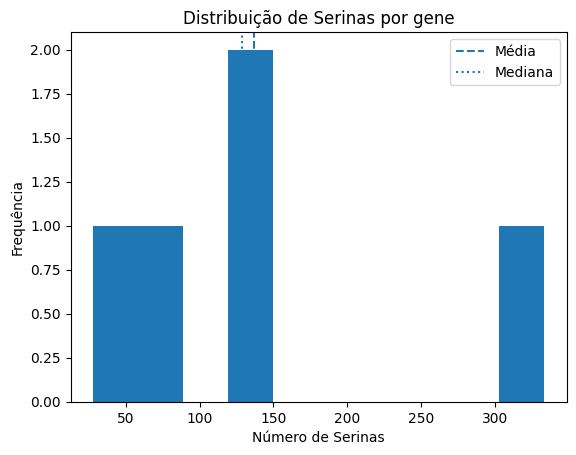

In [20]:
serina = df_final["S"]
media = serina.mean()
mediana = serina.median()

plt.hist(serina)
plt.axvline(media, linestyle="--", label="Média")
plt.axvline(mediana, linestyle=":", label="Mediana")

plt.legend()
plt.title("Distribuição de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [21]:
def histograma_aa(df, aa):
    valores = df[aa]
    
    media = valores.mean()
    mediana = valores.median()
    
    plt.hist(valores)
    plt.axvline(media, linestyle="--", label="Média")
    plt.axvline(mediana, linestyle=":", label="Mediana")
    plt.legend()
    plt.title(f"Distribuição de {aa} por gene")
    plt.xlabel(f"Número de {aa}")
    plt.ylabel("Frequência")
    
    plt.show()

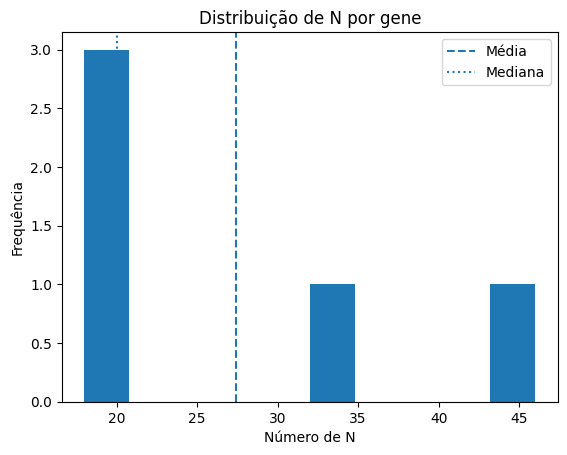

In [22]:
histograma_aa(df_final, "N") #Asparagina

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

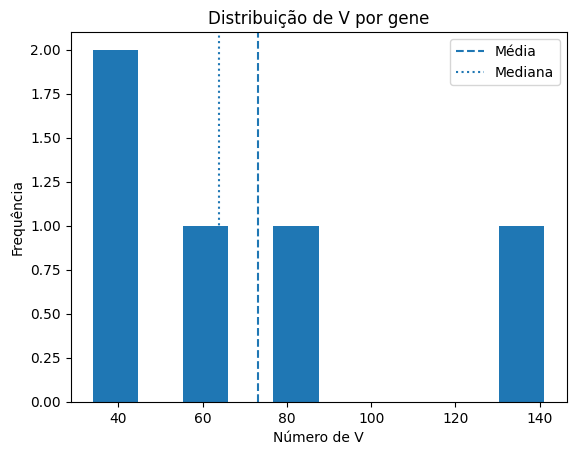

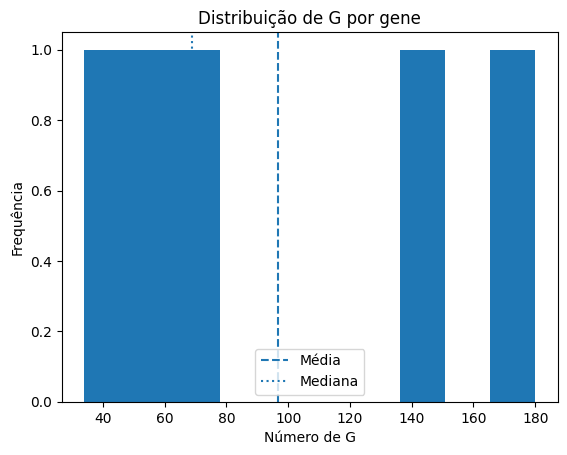

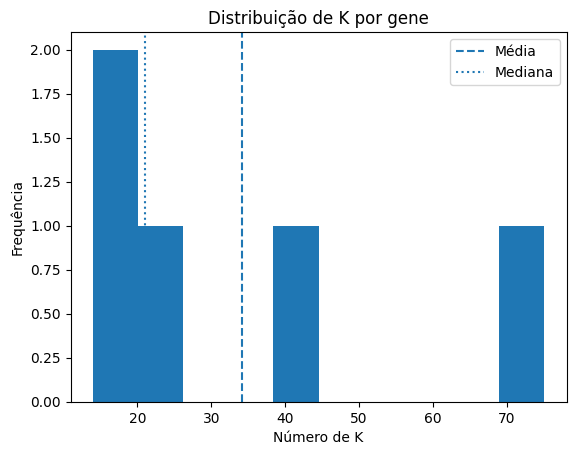

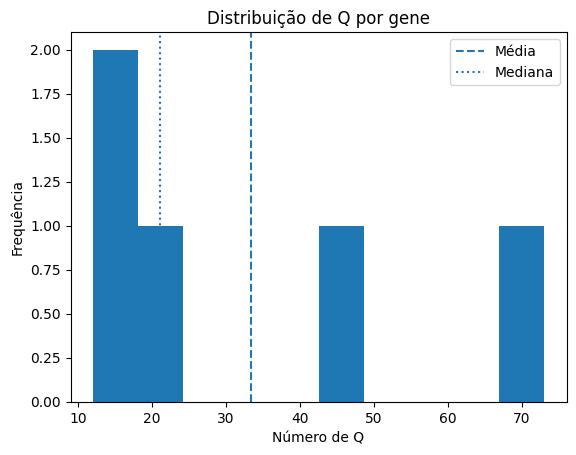

In [23]:
histograma_aa(df_final, "V")  # Valina
histograma_aa(df_final, "G") # Glicina
histograma_aa(df_final, "K") # Lisina
histograma_aa(df_final, "Q") # Glutamina

In [24]:
aas = ["Q", "G", "K", "V"]
resultados = []

for aa in aas:
    media = df_final[aa].mean()
    mediana = df_final[aa].median()
    dif = abs(media - mediana)
    
    resultados.append({
        "aa": aa,
        "media": media,
        "mediana": mediana,
        "diferenca": dif
    })

df_comp = pd.DataFrame(resultados)

df_comp

,aa,media,mediana,diferenca
0,Q,33.4,21.0,12.4
1,G,96.6,69.0,27.6
2,K,34.2,21.0,13.2
3,V,73.2,64.0,9.2


In [25]:
df_menor = df_comp.loc[df_comp["diferenca"].idxmin()]
print("aa com menor diferença:")
df_menor

aa com menor diferença:


aa              V
media        73.2
mediana      64.0
diferenca     9.2
Name: 3, dtype: object

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [26]:
df_3 = df_final.head(3)
df_3

aa,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
ID_gene,,,,,,,,,,,,,,,,,,,,
HDAC1,271,70,106,175,75,180,56,32,75,178,16,46,197,73,187,333,114,141,13,25
HDAC2,61,11,45,38,24,60,18,16,14,49,12,18,42,17,42,64,19,44,6,24
HDAC3,38,9,38,20,24,34,21,21,21,35,10,19,24,12,20,28,14,34,2,27


In [27]:
df_3 = df_final.head(3)

media = df_3["C"].mean()
mediana = df_3["C"].median()

print("Média:", media)
print("Mediana:", mediana)

Média: 30.0
Mediana: 11.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [28]:
df_final["media_aa"] = df_final.mean(axis=1)
maior = df_final.loc[df_final["media_aa"].idxmax()]

print("Gene:", df_final["media_aa"].idxmax())

Gene: HDAC1


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [29]:
df_final["media_aa"] = df_final.mean(axis=1)
menor = df_final.loc[df_final["media_aa"].idxmin()]

print("Gene:", df_final["media_aa"].idxmin())

Gene: HDAC3
